Name : Nisha Yuvraj Pragane | DIV:SEDA | Roll no :13 | PRN : 1252090013 | BATCH :B1

Write a program to do following:
This dataset gives the data of Income and money spent by the customers visiting a shopping mall. The data set contains Customer ID, Gender, Age, Annual Income, Spending Score. Therefore, as a mall owner you need to find the group of people who are the profitable customers for the mall owner. Apply at least two clustering algorithms (based on Spending Score) to find the group of customers.
Apply Data pre-processing
Perform data-preparation (Train-Test Split)
Apply Machine Learning Algorithm
Evaluate Model.
      Data Set: https://www.kaggle.com/shwetabh123/mall-customers

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

Load Dataset

In [ ]:
df = pd.read_csv('Mall_Customers.csv')
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.drop('CustomerID',axis=1,inplace=True)
df

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


Label encoding

In [ ]:
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})
df

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40
...,...,...,...,...
195,1,35,120,79
196,1,45,126,28
197,0,32,126,74
198,0,32,137,18


Select Features

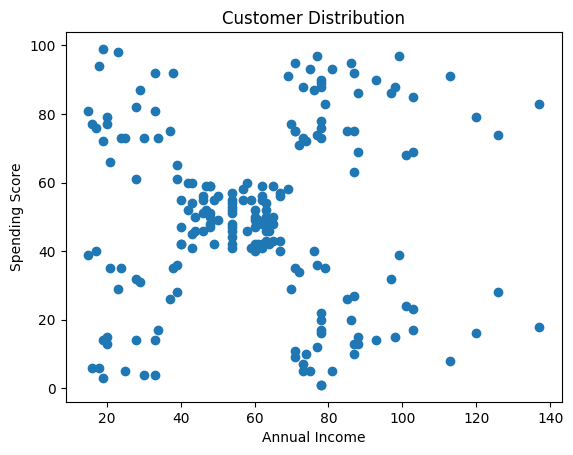

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
plt.scatter(X.iloc[:,0], X.iloc[:,1])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Implementing train test split in 80/20 ratio

In [ ]:
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

Silhouette Score

In [ ]:
kmeans_score1 = silhouette_score(X_scaled, y_kmeans)
print("K-Means Silhouette Score:", kmeans_score1)

K-Means Silhouette Score: 0.5546571631111091


K++

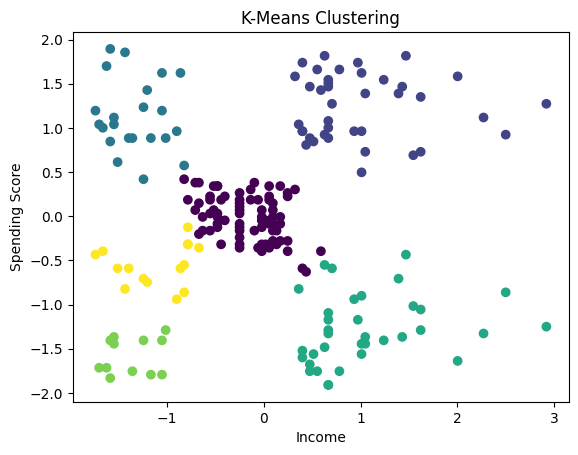

In [ ]:
kmeans3 = KMeans(n_clusters=6, random_state=42)
y_kmeans = kmeans3.fit_predict(X_scaled)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_kmeans, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

Kmeans++

In [ ]:
kmeans_pp = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans_pp = kmeans_pp.fit_predict(X_scaled)

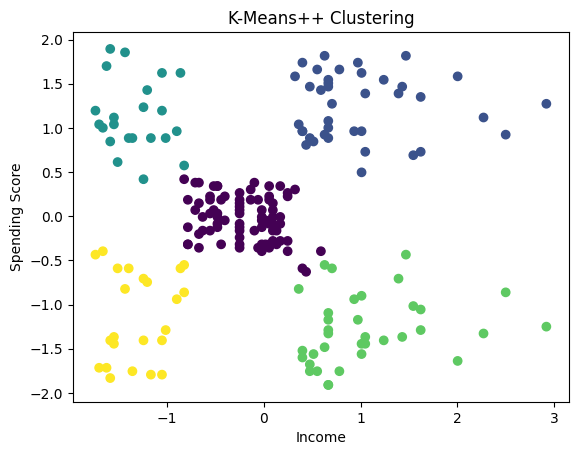

In [ ]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_kmeans_pp, cmap='viridis')
plt.title("K-Means++ Clustering")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

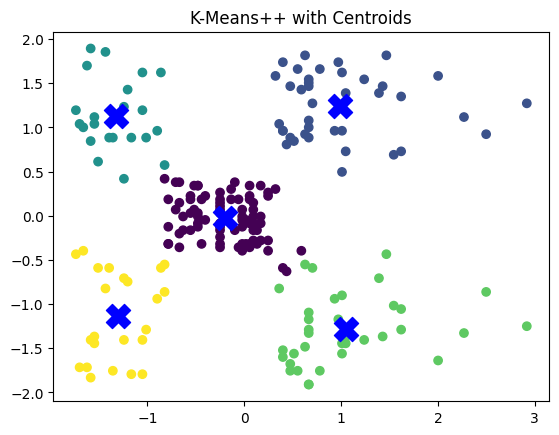

In [ ]:
centroids = kmeans_pp.cluster_centers_

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_kmeans_pp, cmap='viridis')
plt.scatter(centroids[:,0], centroids[:,1], s=300, c='blue', marker='X')
plt.title("K-Means++ with Centroids")
plt.show()

In [ ]:
score_kpp = silhouette_score(X_scaled, y_kmeans_pp)
print("K-Means++ Silhouette Score:", score_kpp)

K-Means++ Silhouette Score: 0.5546571631111091
